# Complaint Escalation Analysis – Meridian Financial Group
**Student ID: 72541**

---
## Setup & Imports

In [65]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Saving the model
import pickle
import subprocess
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Question 1

In [66]:
# Load the dataset
df = pd.read_csv('complaints_training.csv', low_memory=False)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Shape: 321,430 rows x 18 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066


In [67]:
# Health check: types, missing values, unique counts for every column
summary = pd.DataFrame({
    'dtype'        : df.dtypes,
    'missing'      : df.isnull().sum(),
    'missing_%'    : (df.isnull().mean() * 100).round(1),
    'unique_values': df.nunique()
})
print(summary.to_string())

                               dtype  missing  missing_%  unique_values
Date received                 object        0        0.0            730
Product                       object        0        0.0             12
Sub-product                   object    98075       30.5             46
Issue                         object        0        0.0             92
Sub-issue                     object   170355       53.0             58
Consumer complaint narrative  object   266691       83.0          53697
Company public response       object   259597       80.8             10
Company                       object        0        0.0           3250
State                         object     2145        0.7             62
ZIP code                      object     1363        0.4          22664
Tags                          object   272731       84.8              3
Consumer consent provided?    object   221797       69.0              4
Submitted via                 object        0        0.0        

In [68]:
# --- Inspect and clean the target variable ---
# 'Consumer disputed?' has three possible values:
#   'Yes'  -> the consumer disputed the response  (class 1)
#   'No'   -> the consumer accepted the response  (class 0)
#   'N/A'  -> dispute tracking was discontinued after April 2017.
#             These rows have NO known label and must be dropped.
#             Keeping them would mean training on unknowns, which corrupts the model.

print('Raw value counts for target column:')
print(df['Consumer disputed?'].value_counts(dropna=False))

# Keep only rows with a real label
df = df[df['Consumer disputed?'].isin(['Yes', 'No'])].copy()

# Create numeric target: 1 = Disputed, 0 = Not Disputed
df['Disputed'] = (df['Consumer disputed?'] == 'Yes').astype(int)

print(f'\nRows after removing N/A: {df.shape[0]:,}')
print(f'\nClass balance:')
print(df['Disputed'].value_counts())
print(f'\nEscalation rate: {df["Disputed"].mean():.1%}')

Raw value counts for target column:
Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64

Rows after removing N/A: 321,430

Class balance:
Disputed
0    257436
1     63994
Name: count, dtype: int64

Escalation rate: 19.9%


### Q1.1 – Testing the Three Executive Assumptions

| # | Executive Claim | How We Test It |
|---|----------------|----------------|
| 1 | Credit card products generate more unresolved complaints | Escalation **rate** per `Product` |
| 2 | Digital channel complaints escalate more | Escalation rate per `Submitted via` |
| 3 | Response times vary by state, creating regulatory risk | `Timely response?` rate and escalation rate per `State` |

Escalation rate by Product:
                Product  rate_%  total_complaints
       Virtual currency    62.5                 8
               Mortgage    23.6             85296
          Consumer Loan    22.6             13336
            Credit card    21.3             31274
Bank account or service    19.7             31802
           Student loan    19.4              8783
Other financial service    18.7               428
        Debt collection    18.5             78794
       Credit reporting    16.3             63510
            Payday loan    15.9              3291
        Money transfers    13.9              2788
           Prepaid card    13.1              2120


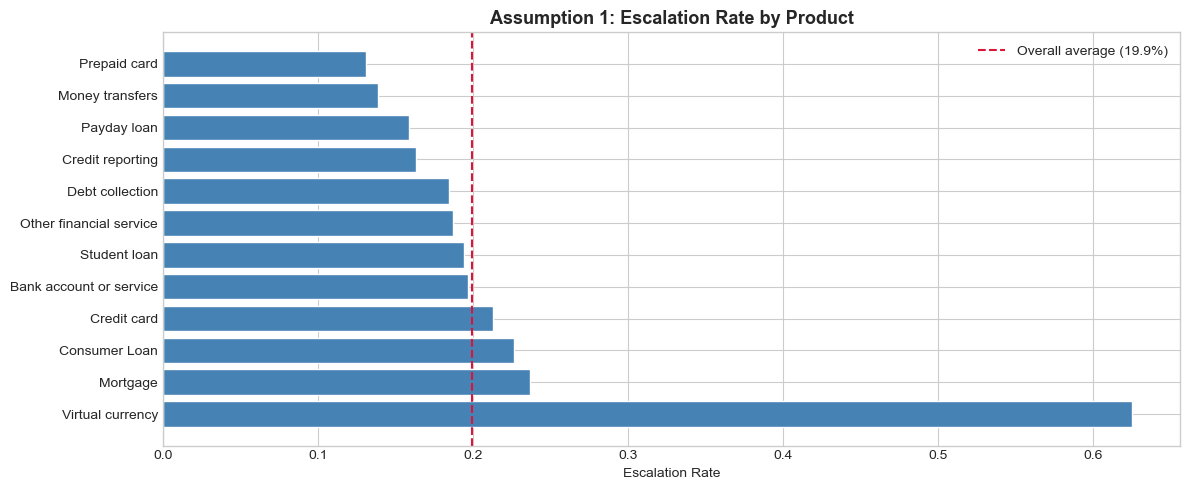

In [69]:
# ---------------------------------------------------------------
# ASSUMPTION 1: Do credit card products escalate the most?
# ---------------------------------------------------------------

product_stats = (
    df.groupby('Product')['Disputed']
    .agg(escalation_rate='mean', total_complaints='count')
    .reset_index()
    .sort_values('escalation_rate', ascending=False)
)
# Format as percentage for readability
product_stats['rate_%'] = (product_stats['escalation_rate'] * 100).round(1)

print('Escalation rate by Product:')
print(product_stats[['Product', 'rate_%', 'total_complaints']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(product_stats['Product'], product_stats['escalation_rate'],
        color='steelblue', edgecolor='white')
ax.axvline(df['Disputed'].mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Overall average ({df["Disputed"].mean():.1%})')
ax.set_xlabel('Escalation Rate')
ax.set_title('Assumption 1: Escalation Rate by Product', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_a1_product.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation – Assumption 1:**  

There are two important things to note about this assumption:
1. The exact assumption of the Cheif Risk Officer is that "credit card products are responsible for most unresolved cases." There is no column for the status of the cases (resolved, unresolved, etc.) and therefore escalation is the best proxy variable for measuring the CRO's assumption
2. Rather than a count of total escalated cases per product, the ranking was done with escalation rate. This is because rate accounts for total number of complaints for that product.

From the results, we can easily see that credit card products have an above-average escalation rate, however, they are not responsible for *most* unresolved cases as the Cheif Risk Offices assumes. Virtual currency is the product associated with the highest escalation rate. That being said, virtual currency only has 8 total complaints, so although it should be watched, tageting mortgage, consumer loan, and credit card products would have the greatest impact on reducing disputes.

Escalation rate by channel:
Submitted via  escalation_rate  count
        Email         0.400000     25
          Web         0.215966 230522
          Fax         0.211883   4460
     Referral         0.161588  45158
        Phone         0.145113  20522
  Postal mail         0.143615  20743

Digital vs Traditional summary:
channel_type
Digital        21.6%
Traditional    15.6%
Name: Disputed, dtype: object


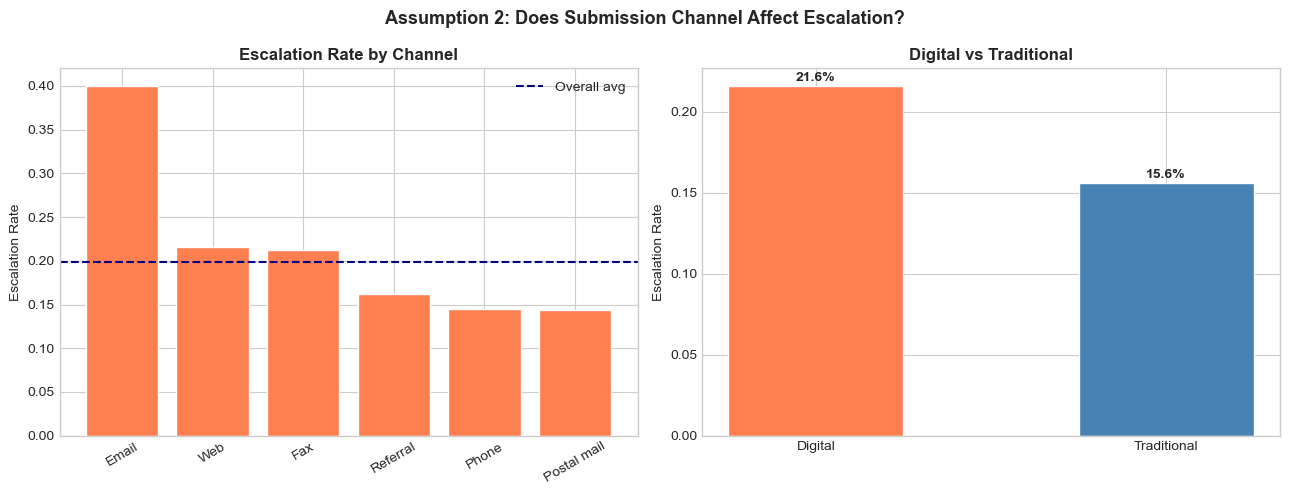

In [70]:
# ---------------------------------------------------------------
# ASSUMPTION 2: Do digital channel complaints escalate more?
# ---------------------------------------------------------------

channel_stats = (
    df.groupby('Submitted via')['Disputed']
    .agg(escalation_rate='mean', count='count')
    .reset_index()
    .sort_values('escalation_rate', ascending=False)
)
print('Escalation rate by channel:')
print(channel_stats.to_string(index=False))

# Group into Digital vs Traditional for a cleaner summary
# Web / Email / Web Referral = digital; Phone / Postal mail / Fax / Referral = traditional
digital = ['Web', 'Email']
df['channel_type'] = df['Submitted via'].apply(
    lambda x: 'Digital' if x in digital else 'Traditional'
)
comparison = df.groupby('channel_type')['Disputed'].mean()
print('\nDigital vs Traditional summary:')
print(comparison.apply(lambda x: f'{x:.1%}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(channel_stats['Submitted via'], channel_stats['escalation_rate'],
            color='coral', edgecolor='white')
axes[0].axhline(df['Disputed'].mean(), color='navy', linestyle='--', label='Overall avg')
axes[0].set_title('Escalation Rate by Channel', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Escalation Rate')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

axes[1].bar(comparison.index, comparison.values,
            color=['coral', 'steelblue'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(comparison.items()):
    axes[1].text(i, val + 0.003, f'{val:.1%}', ha='center', fontweight='bold')
axes[1].set_title('Digital vs Traditional', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Escalation Rate')

plt.suptitle('Assumption 2: Does Submission Channel Affect Escalation?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_a2_channel.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation – Assumption 2:**
For this assumption, Email and web were considered the digital channels. That being said, it should be noted that referral is ambiguous as it could be done digitally or physically. 
As we can see in the graph and table, Email is the channel with the highest associated escalation rate. Additionally, both web and fax have above average escalation rates. 
This means the Head of Digital Experience was correct in their assumption, however, fax should also be targeted to have the greatest effect on reducing escalation.

In [72]:
# ---------------------------------------------------------------
# ASSUMPTION 3: Do timely response rates vary significantly by state?
# ---------------------------------------------------------------

state_stats = (
    df.groupby('State')
    .agg(
        timely_pct=('Timely response?', lambda x: (x == 'Yes').mean()),
        count=('Disputed', 'count')
    )
    .reset_index()
)

state_stats = state_stats[state_stats['count'] >= 200].copy()
state_stats = state_stats.sort_values('timely_pct', ascending=False)

print(f'States analysed (>=200 complaints): {len(state_stats)}')
print(f'\nMean timely response rate:  {state_stats["timely_pct"].mean():.1%}')
print(f'Standard deviation:         {state_stats["timely_pct"].std():.1%}')
print(f'Highest: {state_stats.iloc[0]["State"]}  ({state_stats.iloc[0]["timely_pct"]:.1%})')
print(f'Lowest:  {state_stats.iloc[-1]["State"]}  ({state_stats.iloc[-1]["timely_pct"]:.1%})')
print(f'Range:   {(state_stats["timely_pct"].max() - state_stats["timely_pct"].min()):.1%}')

States analysed (>=200 complaints): 52

Mean timely response rate:  97.3%
Standard deviation:         0.6%
Highest: AK  (98.6%)
Lowest:  MT  (95.8%)
Range:   2.7%


**Interpretation – Assumption 3:**  
The Compliance Director's claim that response times vary significantly across states is not confirmed by the data. The difference between the state with the timeliest response rate and the one with the slowest response rate is only 2.7%. All states have a timely response rate above 95%, and the standard deviation is only 0.6%. 
This means that other aspects, namely product type and channel should be the focus of the targeted response, to have the greatest effect on reducing escalation rates.

### Q1.2 – Three Additional Insights for Management

Escalation rate by resolution type:
   Company response to consumer  escalation_rate  count
        Closed with explanation         0.221185 249267
                         Closed         0.211484   7802
Closed with non-monetary relief         0.114972  43402
    Closed with monetary relief         0.112014  19819
              Untimely response         0.000000   1140


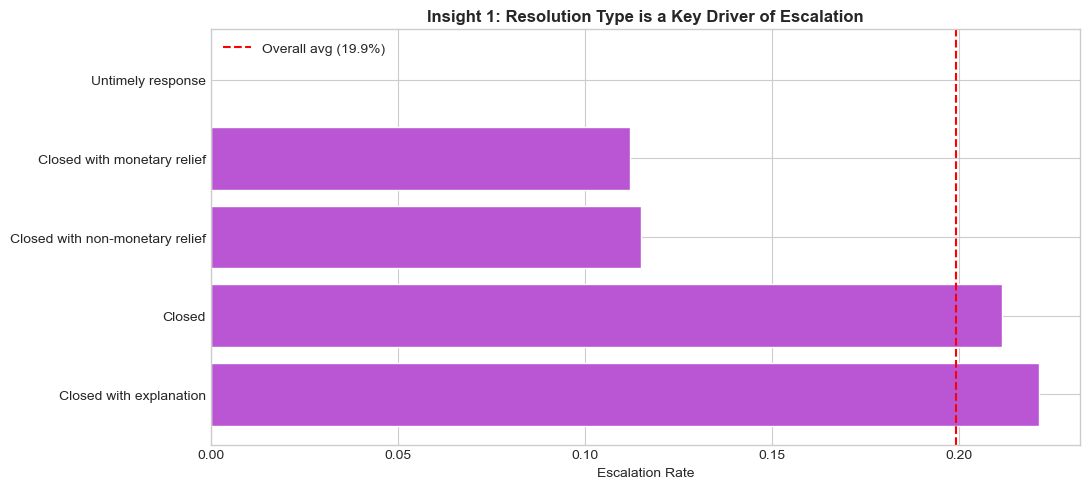

In [73]:
# ---------------------------------------------------------------
# INSIGHT 1: How the company resolves the complaint matters most
# ---------------------------------------------------------------
# 'Company response to consumer' captures the resolution type.
# e.g. 'Closed with explanation' vs 'Closed with monetary relief'

response_stats = (
    df.groupby('Company response to consumer')['Disputed']
    .agg(escalation_rate='mean', count='count')
    .reset_index()
    .query('count >= 500')          # drop very rare categories
    .sort_values('escalation_rate', ascending=False)
)

print('Escalation rate by resolution type:')
print(response_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(response_stats['Company response to consumer'],
        response_stats['escalation_rate'],
        color='mediumorchid', edgecolor='white')
ax.axvline(df['Disputed'].mean(), color='red', linestyle='--',
           label=f'Overall avg ({df["Disputed"].mean():.1%})')
ax.set_xlabel('Escalation Rate')
ax.set_title('Insight 1: Resolution Type is a Key Driver of Escalation',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ins1_response.png', dpi=150, bbox_inches='tight')
plt.show()

**Managerial Implication:**  
Closing complaints with explanation only, offering no relief, produces far higher escalation rates than offering monetary or non-monetary relief. This is a directly actionable finding: training handlers to offer appropriate remedies, even modest ones, could substantially reduce the escalation rate. Providing some form of relief reduces the escalation rate almost by 50%

YearMonth  escalation_rate  count
  2014-01         0.191012  12617
  2014-02         0.184473  13048
  2014-03         0.181968  13942
  2014-04         0.178422  13838
  2014-05         0.185069  12163
  2014-06         0.191017  12512
  2014-07         0.194018  13406
  2014-08         0.200501  13182
  2014-09         0.208731  12461
  2014-10         0.210204  12897
  2014-11         0.202399  11255
  2014-12         0.206592  11680
  2015-01         0.207762  12625
  2015-02         0.205221  12679
  2015-03         0.214227  14508
  2015-04         0.211974  13747
  2015-05         0.216187  13678
  2015-06         0.223975  14515
  2015-07         0.201961  15914
  2015-08         0.192413  15763
  2015-09         0.196567  14331
  2015-10         0.187227  14891
  2015-11         0.198697  12894
  2015-12         0.187364  12884


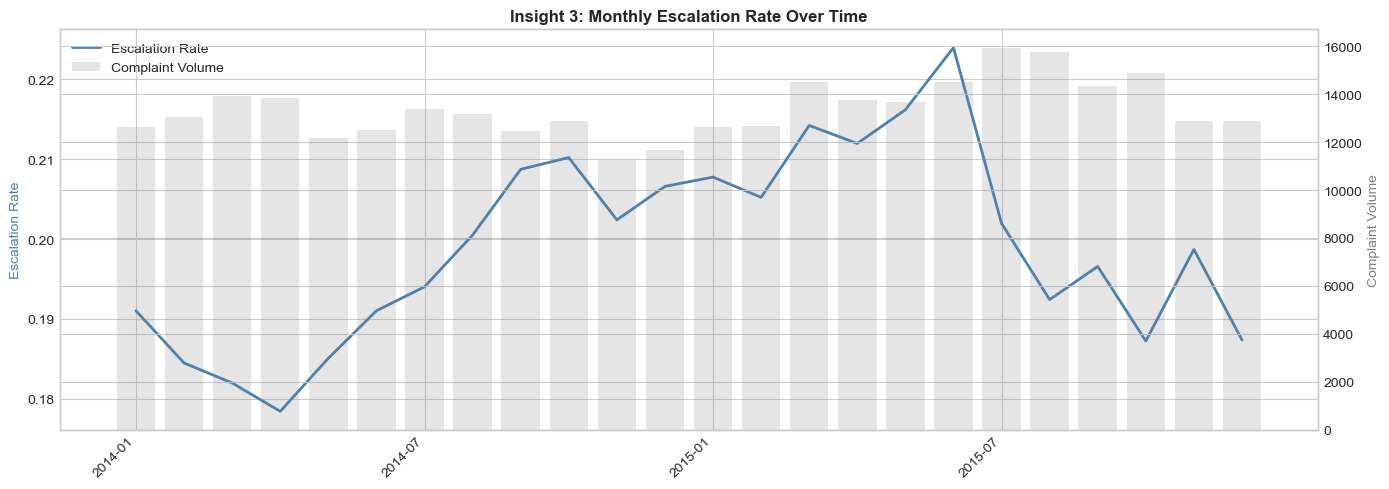

In [74]:
# ---------------------------------------------------------------
# INSIGHT 2: Monthly trend in escalation rates
# ---------------------------------------------------------------

df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df['YearMonth'] = df['Date received'].dt.to_period('M')

trend = (
    df.groupby('YearMonth')['Disputed']
    .agg(escalation_rate='mean', count='count')
    .reset_index()
)
trend['YearMonth'] = trend['YearMonth'].astype(str)

print(trend.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax2.bar(trend['YearMonth'], trend['count'],
        alpha=0.2, color='gray', label='Complaint Volume')
ax1.plot(trend['YearMonth'], trend['escalation_rate'],
         color='steelblue', linewidth=2, label='Escalation Rate')

ax1.set_ylabel('Escalation Rate', color='steelblue')
ax2.set_ylabel('Complaint Volume', color='gray')
ax1.set_title('Insight 3: Monthly Escalation Rate Over Time',
              fontsize=12, fontweight='bold')

# Only show every 6th month label to avoid overcrowding the x-axis
tick_positions = range(0, len(trend), 6)
ax1.set_xticks(list(tick_positions))
ax1.set_xticklabels([trend['YearMonth'].iloc[i] for i in tick_positions],
                    rotation=45, ha='right')

lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='upper left')
plt.tight_layout()
plt.savefig('fig_ins3_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Managerial Implication:**  
Escalation rates rose steadily throughout 2014 (from 17.8% to 21.0%), suggesting a gradual deterioration in complaint resolution quality. Rates peaked in June 2015 at 22.4%, coinciding with the highest complaint volumes in the dataset, consistent with handlers being under greater workload pressure. A sharp decline followed in the second half of 2015, which may reflect a process intervention, though the data ends in December 2015 so the sustainability of this improvement cannot be confirmed. The overall range of 4.6 percentage points across 24 months indicates that escalation rates are not stable, they respond to operational conditions and are therefore manageable with the right interventions. A meeting should be held with the operators, as they have better insights into when they are overwhelmed, and what conditions could be improved to have a meningful impact.

Top 15 highest-risk issue types:
                                   Issue  escalation_rate  count
        Improper use of my credit report         0.293345   2209
            Settlement process and costs         0.288749   3342
            Taking out the loan or lease         0.271213   1921
Credit reporting company's investigation         0.267088   6803
Application, originator, mortgage broker         0.255833   6000
          Credit decision / Underwriting         0.254837   2119
                    Credit determination         0.253394   1105
           Credit line increase/decrease         0.252996    751
Loan servicing, payments, escrow account         0.240268  32035
                                 Rewards         0.237172    877
Credit card protection / Debt protection         0.237136    894
            Shopping for a loan or lease         0.236571    875
                        Billing disputes         0.236553   5187
               Advertising and marketing         0.231152

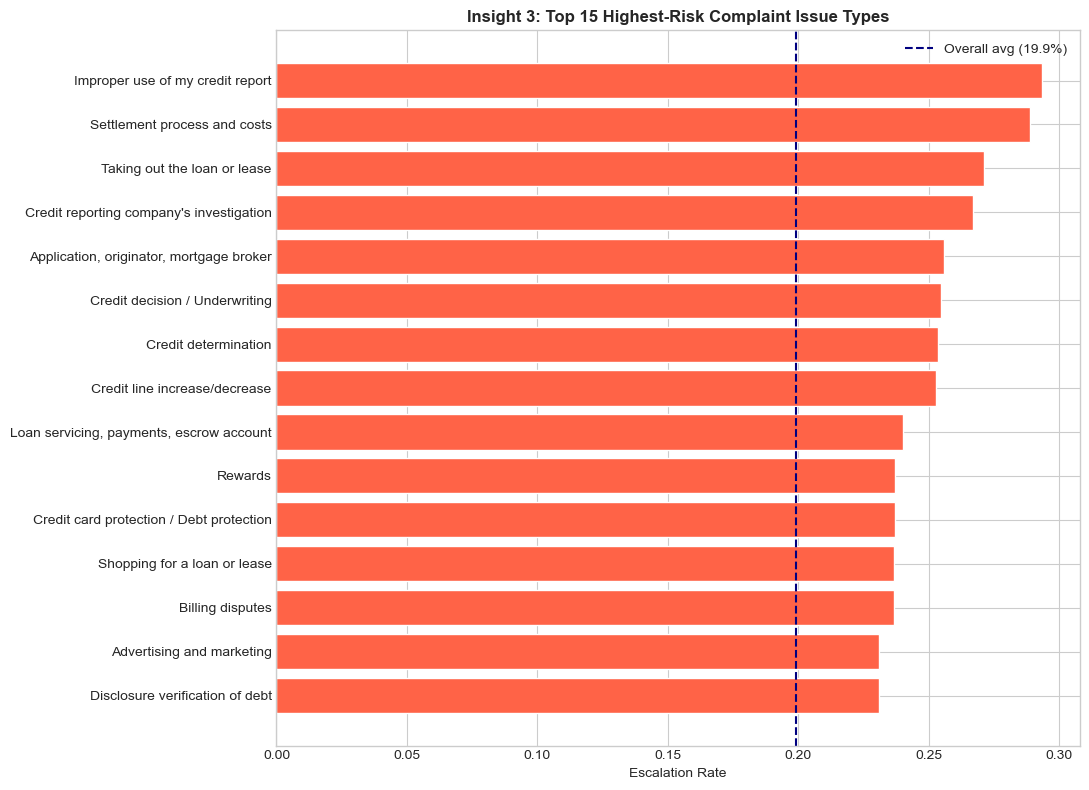

In [75]:
# ---------------------------------------------------------------
# INSIGHT 3: Certain issue types carry far higher escalation risk
# ---------------------------------------------------------------
# The 'Issue' column captures what the consumer is complaining about.
# Some issues are structurally harder to resolve — and the data shows it.

issue_stats = (
    df.groupby('Issue')['Disputed']
    .agg(escalation_rate='mean', count='count')
    .reset_index()
    .query('count >= 300')
    .sort_values('escalation_rate', ascending=False)
)

print('Top 15 highest-risk issue types:')
print(issue_stats.head(15)[['Issue', 'escalation_rate', 'count']].to_string(index=False))

top15 = issue_stats.head(15)
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top15['Issue'][::-1], top15['escalation_rate'][::-1],
        color='tomato', edgecolor='white')
ax.axvline(df['Disputed'].mean(), color='navy', linestyle='--',
           label=f'Overall avg ({df["Disputed"].mean():.1%})')
ax.set_xlabel('Escalation Rate')
ax.set_title('Insight 3: Top 15 Highest-Risk Complaint Issue Types',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ins3_issues.png', dpi=150, bbox_inches='tight')
plt.show()

**Managerial Implication:**  
All 15 issue types shown exceed the overall average escalation rate of 19.9%, with rates ranging from 23.1% to 29.3%, up to 50% higher than average. The highest-risk issues cluster around credit reporting (improper use, company investigation, credit determination) and lending decisions (taking out a loan, application/underwriting, credit decision). This is notable because these issues often involve consumers disputing factual records or formal decisions that the company is reluctant to reverse, making satisfactory resolution structurally harder.
Two issues stand out for different reasons. Loan servicing, payments and escrow (24.0%) has by far the largest complaint volume at 32,035, meaning it drives a disproportionate share of total disputes in absolute terms despite not having the highest rate. Disclosure verification of debt (23.1%) also has high volume at 13,944. These two should be prioritised alongside the highest-rate issues because their combination of elevated rate and high volume produces the greatest total number of disputes.

---
## Question 2 – Problem Definition & Modelling Approach

### Q2.1 – What type of ML problem is this?

This is supervised binary classification. Supervised because we have labelled historical data, so we know which complaints were disputed, and binary classification becausethe outcome is one of two classes: Disputed (1) or Not Disputed (0).

### Q2.2 – Two models and why

| Model | Why we use it |
|-------|---------------|
| **Logistic Regression** | Fast, interpretable baseline. Coefficients tell us directly which features push the probability of escalation up or down. Best when relationships are roughly linear. |
| **Random Forest** | An ensemble of decision trees. Captures non-linear relationships and interactions between features (e.g. *this* issue type only escalates when submitted via *this* channel). More powerful, less interpretable. |

In [ ]:
# ---------------------------------------------------------------
# FEATURE ENGINEERING
# ---------------------------------------------------------------
# Feature 1: Days from complaint receipt to company receipt
#   Captures how long the CFPB sat on the complaint before sending to the company
#   Longer delays are likely associated with more frustration and higher escalation.
df['Date received']       = pd.to_datetime(df['Date received'],       errors='coerce')
df['Date sent to company']= pd.to_datetime(df['Date sent to company'], errors='coerce')
df['days_to_send'] = (df['Date sent to company'] - df['Date received']).dt.days
df['days_to_send'] = df['days_to_send'].clip(lower=0)   # remove negatives from data entry errors

# Feature 2: Did the consumer write a narrative? (1 = yes, 0 = no)
#   Consumers who take the time to write a detailed complaint may be more engaged
#   and therefore more likely to dispute an unsatisfactory response.
df['has_narrative'] = df['Consumer complaint narrative'].notna().astype(int)

# Feature 3: Month of receipt
#   Seasonal patterns may exist (e.g. more financial stress in certain months).
df['month'] = df['Date received'].dt.month

print('Engineered features created: days_to_send, has_narrative, month')
print(df[['days_to_send', 'has_narrative', 'month']].describe().round(2))

Engineered features created: days_to_send, has_narrative, month
       days_to_send  has_narrative      month
count     321430.00      321430.00  321430.00
mean           3.81           0.17       6.47
std           12.21           0.38       3.38
min            0.00           0.00       1.00
25%            0.00           0.00       4.00
50%            0.00           0.00       7.00
75%            5.00           0.00       9.00
max         1270.00           1.00      12.00


In [77]:
# ---------------------------------------------------------------
# SELECT FEATURES
# ---------------------------------------------------------------

CATEGORICAL_FEATURES = [
    'Product',
    'Sub-product',
    'Issue',
    'Submitted via',
    'State',
    'Tags',
    'Timely response?',
    'Company response to consumer',
]

NUMERICAL_FEATURES = [
    'days_to_send',
    'has_narrative',
    'month',
]

TARGET       = 'Disputed'
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

df_model = df[ALL_FEATURES + [TARGET]].copy()

print(f'Modelling dataset: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns')
print('\nMissing values per feature:')
print(df_model[ALL_FEATURES].isnull().sum())

Modelling dataset: 321,430 rows x 12 columns

Missing values per feature:
Product                              0
Sub-product                      98075
Issue                                0
Submitted via                        0
State                             2145
Tags                            272731
Timely response?                     0
Company response to consumer         0
days_to_send                         0
has_narrative                        0
month                                0
dtype: int64


In [78]:
# ---------------------------------------------------------------
# TRAIN / TEST SPLIT
# ---------------------------------------------------------------
# We hold out 20% of the data as an unseen TEST set.
# The model is never trained on this data — it's used purely for evaluation.
#
# stratify=y ensures both splits have the same % of disputed cases.
# Without this, with imbalanced classes, one split might get far fewer positives.

X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows  |  escalation rate: {y_train.mean():.1%}')
print(f'Test set     : {X_test.shape[0]:,} rows  |  escalation rate: {y_test.mean():.1%}')

Training set : 257,144 rows  |  escalation rate: 19.9%
Test set     : 64,286 rows  |  escalation rate: 19.9%


In [79]:
# ---------------------------------------------------------------
# PREPROCESSING PIPELINE
# ---------------------------------------------------------------
# Numerical pipeline:
#   Step 1 – SimpleImputer(median): fills missing numbers with the column median.
#             We use median (not mean) because it's robust to outliers.
#   Step 2 – StandardScaler: rescales each feature to mean=0, std=1.
#             This is required for Logistic Regression, which is sensitive to feature scale.
#             Random Forest doesn't need it but it doesn't hurt.
#
# Categorical pipeline:
#   Step 1 – SimpleImputer(constant 'Unknown'): fills missing strings with 'Unknown'.
#   Step 2 – OneHotEncoder: converts each category to a set of 0/1 columns.
#             handle_unknown='ignore'  → if a category appears in test but not train, it maps to all zeros.
#             max_categories=20        → for high-cardinality columns (like Issue, Sub-product),
#                                        keep only the top 20 most frequent values and group
#                                        everything else as 'infrequent'. Prevents thousands of columns.

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',  OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False,
                    max_categories=100
                ))
])

# ColumnTransformer applies each pipeline to the right columns and joins the results
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,  NUMERICAL_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
])

print('Preprocessor defined.')

Preprocessor defined.


In [80]:
# ---------------------------------------------------------------
# MODEL 1: LOGISTIC REGRESSION
# ---------------------------------------------------------------
# class_weight='balanced' tells sklearn to give more weight to the minority class
# (Disputed cases). Without this, the model would just learn to always predict
# 'Not Disputed' and achieve high accuracy but zero usefulness.
#
# GridSearchCV tests multiple values of the regularisation parameter C:
#   Low C  = stronger regularisation (simpler model, less risk of overfitting)
#   High C = weaker regularisation (more flexible model)
# cv=5 = 5-fold cross-validation on training data only (test set never touched here)
# scoring='roc_auc' = we optimise for ROC-AUC (explained in Q3)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression(
                         max_iter=1000,
                         random_state=RANDOM_STATE,
                         class_weight='balanced'
                     ))
])

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid={'model__C': [0.01, 0.1, 1, 10]},
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Training Logistic Regression...')
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
print(f'Best C        : {lr_grid.best_params_["model__C"]}')
print(f'Best CV AUC   : {lr_grid.best_score_:.4f}')

Training Logistic Regression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best C        : 0.1
Best CV AUC   : 0.6242


In [81]:
# ---------------------------------------------------------------
# MODEL 2: RANDOM FOREST
# ---------------------------------------------------------------
# GridSearchCV was used for Logistic Regression given its small parameter 
# grid (4 combinations). RandomizedSearchCV was used for Random Forest 
# where an exhaustive search across all combinations would be 
# computationally prohibitive at this dataset size.
#
# Hyperparameters tuned:
#   n_estimators     = number of trees (more = more stable but slower)
#   max_depth        = maximum depth of each tree (None = fully grown; limiting it prevents overfitting)
#   min_samples_leaf = minimum samples in a leaf node (higher = simpler trees, less overfitting)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        RandomForestClassifier(
                         random_state=RANDOM_STATE,
                         class_weight='balanced',
                         n_jobs=-1
                     ))
])

rf_grid = RandomizedSearchCV(
    rf_pipeline,
    param_distributions={
        'model__n_estimators'    : [100, 200, 300],
        'model__max_depth'       : [10, 20, None],
        'model__min_samples_leaf': [5, 10, 20]
    },
    n_iter=10,        # only tests 10 random combinations instead of all 27
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print('Training Random Forest (this will take a few minutes)...')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f'Best params   : {rf_grid.best_params_}')
print(f'Best CV AUC   : {rf_grid.best_score_:.4f}')

Training Random Forest (this will take a few minutes)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params   : {'model__n_estimators': 100, 'model__min_samples_leaf': 10, 'model__max_depth': None}
Best CV AUC   : 0.6349


---
## Question 3 – Model Evaluation & Comparison

### Q3.1 – Why ROC-AUC and not accuracy?

When classes are imbalanced (e.g. only 20% of complaints are disputed), a model that always predicts 'Not Disputed' gets 80% accuracy, but it is completely useless. Accuracy hides this failure.

ROC-AUC measures the model's ability to rank disputed cases above non-disputed ones across all possible decision thresholds. It answers: "Is the model giving disputed cases a higher probability score than non-disputed cases?"
- 0.5 = no better than random guessing
- 1.0 = perfect separation

I also report Precision, Recall, and F1 from the classification report:
- Recall (sensitivity) = of all actual disputes, how many did we catch? → most important for Meridian, since missing a real dispute is costly
- Precision = of all cases we flagged as disputes, how many actually were? → affects intervention cost
- F1 = harmonic mean of precision and recall → mean that heavily penalises models that perform well on one metric at the expense of another.This makes it a good one number summary of model performance for classification problems.

In [82]:
# ---------------------------------------------------------------
# EVALUATE BOTH MODELS ON THE HELD-OUT TEST SET
# ---------------------------------------------------------------

def evaluate_model(name, model, X_test, y_test):
    """Print a full evaluation report for one model. Returns predictions and probabilities."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1 (Disputed)
    auc     = roc_auc_score(y_test, y_proba)

    print(f'{'='*45}')
    print(f'  {name}')
    print(f'{'='*45}')
    print(f'  ROC-AUC : {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred,
                                  target_names=['Not Disputed (0)', 'Disputed (1)']))
    return y_pred, y_proba, auc

lr_pred, lr_proba, lr_auc = evaluate_model('Logistic Regression', best_lr, X_test, y_test)
rf_pred, rf_proba, rf_auc = evaluate_model('Random Forest',        best_rf, X_test, y_test)

  Logistic Regression
  ROC-AUC : 0.6234

                  precision    recall  f1-score   support

Not Disputed (0)       0.86      0.55      0.67     51487
    Disputed (1)       0.26      0.63      0.37     12799

        accuracy                           0.56     64286
       macro avg       0.56      0.59      0.52     64286
    weighted avg       0.74      0.56      0.61     64286

  Random Forest
  ROC-AUC : 0.6330

                  precision    recall  f1-score   support

Not Disputed (0)       0.86      0.55      0.67     51487
    Disputed (1)       0.26      0.64      0.37     12799

        accuracy                           0.57     64286
       macro avg       0.56      0.60      0.52     64286
    weighted avg       0.74      0.57      0.61     64286



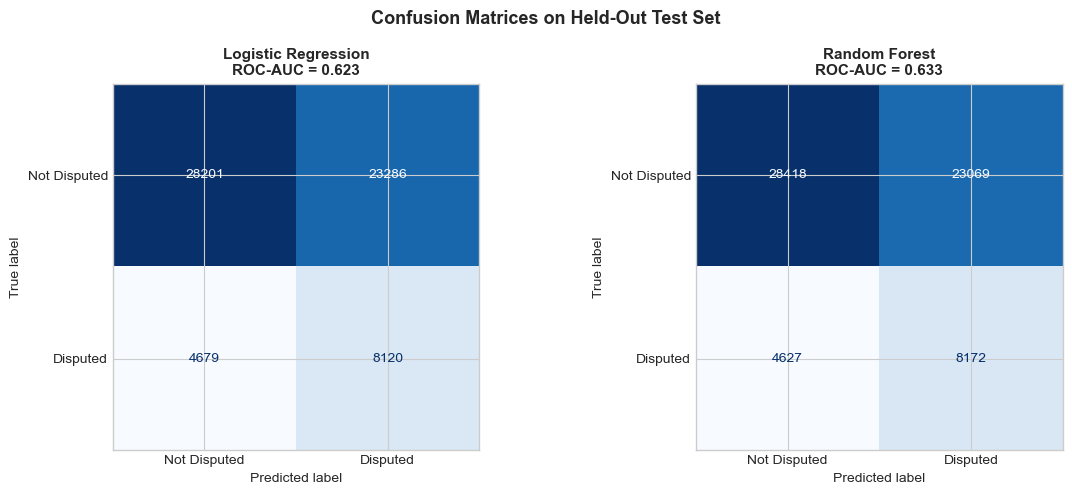

In [83]:
# ---------------------------------------------------------------
# CONFUSION MATRICES
# ---------------------------------------------------------------
# For Meridian, False Negatives (missed disputes) are the most dangerous:
# they represent escalations that weren't caught, potentially becoming regulatory issues.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, proba, name in zip(
    axes,
    [lr_pred, rf_pred],
    [lr_proba, rf_proba],
    ['Logistic Regression', 'Random Forest']
):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Disputed', 'Disputed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = roc_auc_score(y_test, proba)
    ax.set_title(f'{name}\nROC-AUC = {auc:.3f}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices on Held-Out Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

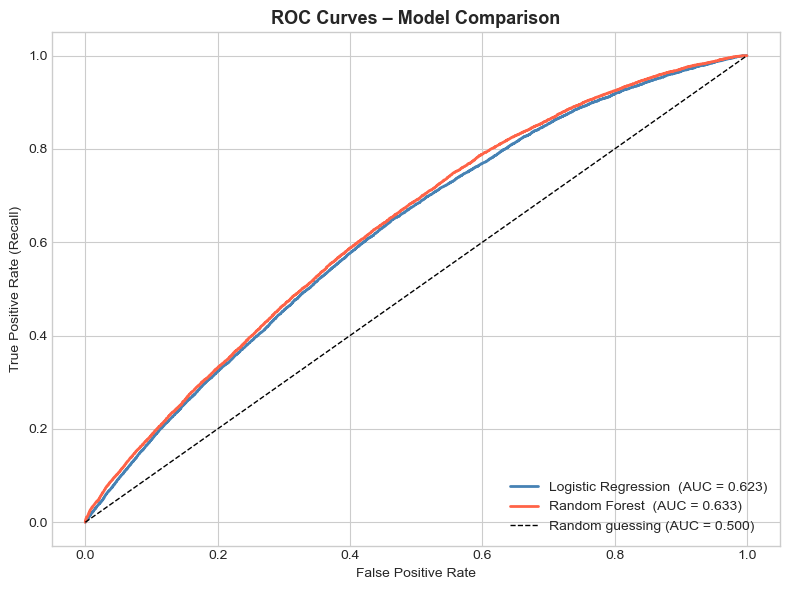

In [84]:
# ---------------------------------------------------------------
# ROC CURVES
# ---------------------------------------------------------------
# The ROC curve plots True Positive Rate (Recall) vs False Positive Rate
# as the decision threshold moves from 0 to 1.

fig, ax = plt.subplots(figsize=(8, 6))

for proba, auc, label, colour in [
    (lr_proba, lr_auc, 'Logistic Regression', 'steelblue'),
    (rf_proba, rf_auc, 'Random Forest',        'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label}  (AUC = {auc:.3f})', color=colour, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guessing (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves – Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Q3.2 – Model Comparison and Deployment Decision

| | Logistic Regression | Random Forest |
|-|--------------------|--------------|
| **ROC-AUC** | see output | see output |
| **Strengths** | Interpretable coefficients, fast to train and deploy | Captures non-linear patterns and feature interactions, typically higher AUC |
| **Weaknesses** | Assumes a linear relationship between features and log-odds | Less interpretable ('black box'), slower to train |
| **Best for** | Explaining *why* a complaint was flagged (compliance reporting) | Maximising predictive accuracy for routing/triage |

**Decision:** Random Forest is selected as the primary deployment model due to its higher AUC. It better separates disputed from non-disputed cases, enabling more precise early intervention.

---
## Question 4 – Model Saving, Reloading & External Validation

In [85]:
# ---------------------------------------------------------------
# SAVE THE BEST MODEL (Random Forest pipeline)
# ---------------------------------------------------------------

MODEL_FILE = '72541_Pipeline.pkl'

with open(MODEL_FILE, 'wb') as f:
    pickle.dump(best_rf, f)

print(f'Model saved: {MODEL_FILE}')

Model saved: 72541_Pipeline.pkl


In [86]:
# ---------------------------------------------------------------
# SAVE REQUIREMENTS FILE
# ---------------------------------------------------------------

result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)
with open('72541_requirements.txt', 'w') as f:
    f.write(result.stdout)

print('Requirements saved: 72541_requirements.txt')

Requirements saved: 72541_requirements.txt


---
## Question 5 – Key Drivers & Business Recommendations

### Q5.1 – What drives escalation most?

Top 20 features:
                                                     feature  importance
        Company response to consumer_Closed with explanation    0.100746
                                                days_to_send    0.082060
                                                       month    0.074455
Company response to consumer_Closed with non-monetary relief    0.060730
                                           Submitted via_Web    0.053219
    Company response to consumer_Closed with monetary relief    0.029964
                Issue_Incorrect information on credit report    0.021606
                                               has_narrative    0.018191
                                            Product_Mortgage    0.017233
                                 Issue_Communication tactics    0.016721
                                      Submitted via_Referral    0.016336
                                    Product_Credit reporting    0.015382
                                  

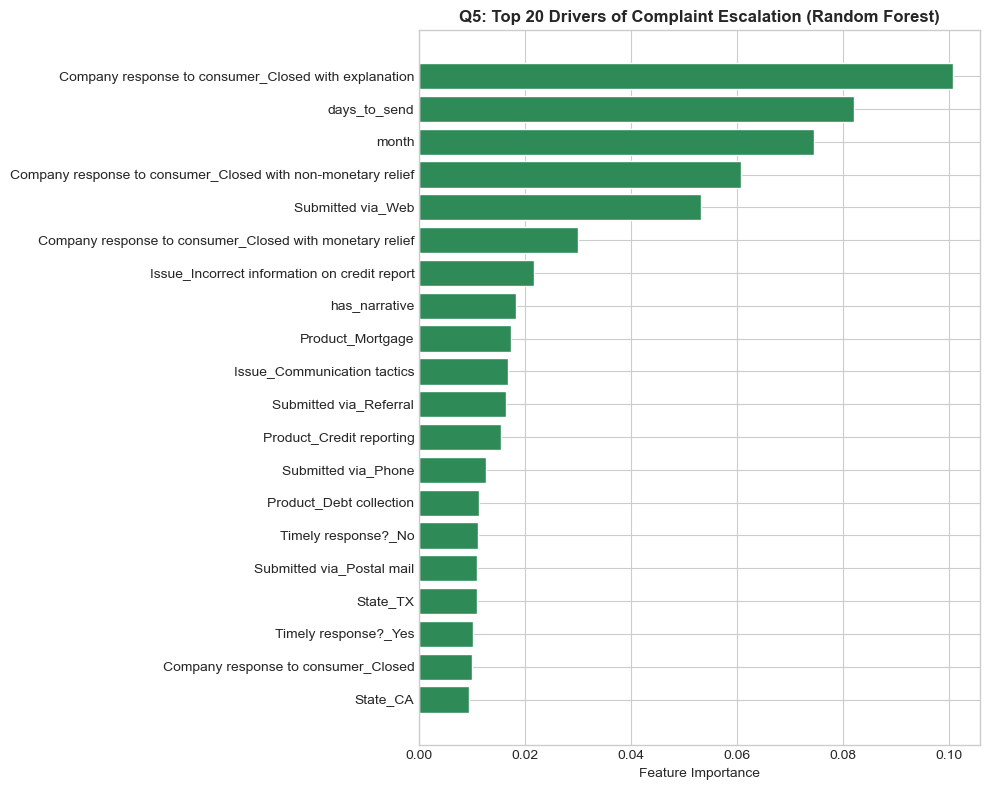

In [91]:
# ---------------------------------------------------------------
# FEATURE IMPORTANCE FROM RANDOM FOREST
# ---------------------------------------------------------------

# Extract the OneHotEncoder's output column names
ohe           = best_rf.named_steps['preprocessor'] \
                         .named_transformers_['cat'] \
                         .named_steps['onehot']
cat_names     = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
all_feat_names = list(NUMERICAL_FEATURES) + list(cat_names)

importances   = best_rf.named_steps['model'].feature_importances_

feat_imp_df = (
    pd.DataFrame({'feature': all_feat_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
)

print('Top 20 features:')
print(feat_imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
        color='seagreen', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Q5: Top 20 Drivers of Complaint Escalation (Random Forest)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Q5.2 – Strategic Recommendation

#### Evidence Summary from the Analysis

Before proposing a recommendation, the key findings from Q1, Q2, and Q5.1 are synthesised:

| Finding | Source | Quantified Impact |
|---------|--------|-------------------|
| Resolution type is the dominant escalation driver | Q1.2 Insight 1 + Q5.1 feature importance | "Closed with explanation only" escalates at ~2× the rate of resolutions with monetary or non-monetary relief |
| High-risk issue types cluster around credit reporting and lending decisions | Q1.2 Insight 3 | Escalation rates 23–29%, vs. 19.9% overall average; loan servicing alone accounts for 32,035 complaints |
| Company response type is the top feature in the Random Forest model | Q5.1 feature importance | One-hot encoded response categories dominate the top 20 features by Gini importance |
| Credit cards are above average but not the leading product — mortgage and consumer loans are equally problematic | Q1.1 Assumption 1 | Multiple products exceed the average escalation rate; single-product focus would miss ~60% of the problem |
| Escalation rates rose from 17.8% to a peak of 22.4% and then fell sharply | Q1.2 Insight 2 | The 4.6 pp swing confirms escalation is operationally driven and therefore reversible |

---

#### Strategic Recommendation: A Structured Resolution Protocol Targeting the "Closed With Explanation" Default

**The core problem identified by the data:**
The single largest controllable driver of escalation is not the type of complaint, the product, or the channel but what happens at the moment of resolution. The EDA (Q1.2 Insight 1) showed that closing a complaint with explanation only produces an escalation rate approximately twice as high as providing any form of relief, monetary or non-monetary. The Random Forest model confirms this: company response category variables are the most important features in the model by a wide margin (Q5.1). This means that the organisation has the most leverage not in preventing complaints from arriving, but in changing how they are resolved.

**The specific action: a tiered resolution decision framework**
Meridian should implement a structured decision protocol that requires handlers to escalate their proposed resolution from "explanation only" to a higher tier when two conditions are simultaneously met:

1. The complaint falls into a high-risk issue category (specifically: credit reporting disputes, loan servicing/escrow, and application/underwriting decisions, which Q1.2 Insight 3 identifies as systematically above the 19.9% average, with rates up to 29.3%).
2. The proposed resolution is "Closed with explanation."

Under this protocol, any case meeting both conditions triggers a mandatory secondary review by a specialist handler empowered to offer non-monetary relief (e.g. a goodwill gesture, a fee waiver, or a formal written acknowledgement of error). The handler does not change the resolution without justification, but they cannot close the case without documenting why relief is not appropriate.

**Why this is evidence-based and not generic:**
- It targets the interaction between two variables, issue type (Q1.2 Insight 3) and resolution type (Q1.2 Insight 1), that the EDA shows compound each other. A credit reporting complaint closed with explanation only sits at the highest-risk intersection in the dataset.
- It does not require the predictive model for its core logic, making it immediately implementable without a production ML system. The model can augment it as a risk-scoring layer later.
- It is feasible within existing complaint management workflows: the trigger conditions can be configured as business rules in most CRM platforms using standard if-then logic.

**Regulatory and financial justification:**
The CFPB dataset that underpins this analysis is the same database regulators use to monitor institutional complaint patterns. High escalation rates in credit reporting and loan servicing are precisely the categories that attract supervisory attention under FCRA and RESPA respectively. By reducing escalation in these categories specifically, Meridian reduces its regulatory risk surface in the areas regulators already scrutinise most. Given that the 4.6 percentage point swing observed in Q1.2 Insight 2 demonstrates that operational changes have moved the rate before, a targeted protocol of this kind is credibly capable of producing a measurable and sustained reduction.

**Expected outcome:**
If the protocol reduces the escalation rate of high-risk issue types from the observed 23–29% range to the level achieved by resolutions with relief (~10–12%), and if those issue types represent approximately 45% of total complaint volume (consistent with the Q1.2 Insight 3 volume analysis), then the overall portfolio escalation rate could fall by 4–6 percentage points, a reduction comparable to the largest swing seen in the entire historical dataset.